<a href="https://colab.research.google.com/github/Manikanta-Rajulapati2002/GAN-Data-Poisoning-MNIST-Sentiment/blob/main/GAN_Programming.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GAN Programming Task Using PyTorch

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.17MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:06<00:00, 244kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.58MB/s]


Saved sample at epoch 0
Saved sample at epoch 50
Saved sample at epoch 100


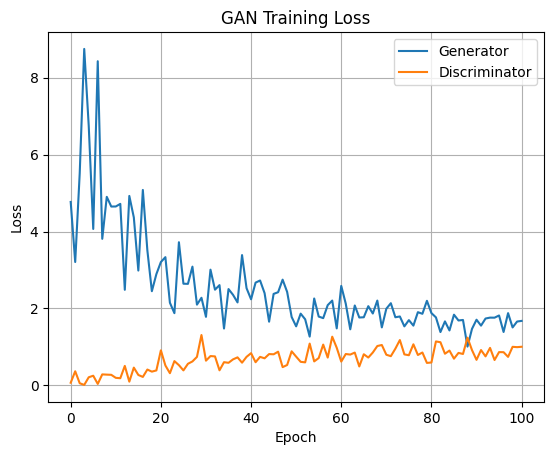

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Generator model
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

# Discriminator model
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

# Load MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

# Initialize models
G = Generator()
D = Discriminator()

# Loss and optimizers
criterion = nn.BCELoss()
optimizerG = optim.Adam(G.parameters(), lr=0.0002)
optimizerD = optim.Adam(D.parameters(), lr=0.0002)

# Fixed noise for tracking generation
fixed_noise = torch.randn(64, 100)
G_losses = []
D_losses = []

# Training Loop
for epoch in range(101):
    for real, _ in loader:
        real = real.view(-1, 784)
        b_size = real.size(0)

        # Labels
        label_real = torch.ones(b_size, 1)
        label_fake = torch.zeros(b_size, 1)

        # === Train Discriminator ===
        D.zero_grad()
        output_real = D(real)
        lossD_real = criterion(output_real, label_real)

        noise = torch.randn(b_size, 100)
        fake = G(noise)
        output_fake = D(fake.detach())
        lossD_fake = criterion(output_fake, label_fake)

        lossD = lossD_real + lossD_fake
        lossD.backward()
        optimizerD.step()

        # === Train Generator ===
        G.zero_grad()
        output = D(fake)
        lossG = criterion(output, label_real)
        lossG.backward()
        optimizerG.step()

    G_losses.append(lossG.item())
    D_losses.append(lossD.item())

    # Save sample generated images at epochs 0, 50, 100
    if epoch in [0, 50, 100]:
        with torch.no_grad():
            generated = G(fixed_noise).view(-1, 1, 28, 28)
            torchvision.utils.save_image(generated, f"gen_epoch_{epoch}.png", nrow=8, normalize=True)
            print(f"Saved sample at epoch {epoch}")

# Plot Losses
plt.plot(G_losses, label='Generator')
plt.plot(D_losses, label='Discriminator')
plt.title("GAN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig("gan_loss_plot.png")
plt.show()
